# Summary

Parameter space vs. performance. In the manuscript: **Fig. 2C-D**.

---
# Setup


In [1]:
# imports
import os 
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from popy.simulation_tools import QLearner, ForagingAgent
from popy.simulation_helpers import simulate_agent
from popy.config import COLORS
import popy.config as cfg

from popy.config import PROJECT_PATH_LOCAL, COLORS
results_dir = os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "bootstrap")


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-raypasbs because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [36]:
# local functions
def grid_search_RL(env, n_samples=15):
    alpha_range = np.linspace(.01, .5, n_samples)  # learning rate range

    res_grid_qlearn_inferential = np.zeros(len(alpha_range))  # to store results
        
    for i, alpha in enumerate(alpha_range):
        params_temp = {'alpha': alpha}
        behavior_temp = simulate_agent(QLearner, params=params_temp, env=env, fixed_params={'structure_aware': True, 'stickiness_bias': 0})  # simulate inferential Q-learning agent (structure-aware means inferential RL setup)

        # compute proportion of best arm selections
        prop_best_arm = (behavior_temp["best_arm"].values == behavior_temp["action"].values).mean()
        res_grid_qlearn_inferential[i] = prop_best_arm 

    return alpha_range, res_grid_qlearn_inferential

def grid_search_sRL(env, n_samples=15):
    n_samples = 15  # number of samples in the grid search
    alpha_range = np.linspace(.01, .5, n_samples)  # learning rate range
    stickiness_range = np.linspace(0, 5, n_samples)  # stickiness bias range

    res_grid_qlearn_inferential = np.zeros((len(alpha_range), len(stickiness_range)))  # to store results
        
    for i, alpha in enumerate(alpha_range):
        for j, stickiness in enumerate(stickiness_range):
            params_temp = {'alpha': alpha, 'stickiness_bias': stickiness}
            behavior_temp = simulate_agent(QLearner, params=params_temp, env=env, fixed_params={'structure_aware': True})  # simulate inferential Q-learning agent (structure-aware means inferential RL setup)

            # compute proportion of best arm selections
            prop_best_arm = (behavior_temp["best_arm"].values == behavior_temp["action"].values).mean()
            res_grid_qlearn_inferential[i, j] = prop_best_arm 
    return alpha_range, stickiness_range, res_grid_qlearn_inferential

def grid_search_foraging(env):
    n_samples = 15  # number of samples in the grid search (per parameter)
    alpha_range = np.linspace(.05, .8, n_samples)  # learning rate range
    V0_range = np.linspace(0, .75, n_samples)

    res_grid = np.zeros((len(alpha_range), len(V0_range)))  # to store results

    for i, alpha in enumerate(alpha_range):
        for j, V0 in enumerate(V0_range):
            params_temp = {
                'alpha': alpha,
                'V0': V0
            }
            behavior = simulate_agent(ForagingAgent, params=params_temp, env=env, fixed_params={'reset_on_switch': True})  # simulate foraging agent (reset value on switching)

            # compute proportion of best arm selection
            prop_best_arm = (behavior["best_arm"].values == behavior["action"].values).mean()
            res_grid[i, j] = prop_best_arm 

    return alpha_range, V0_range, res_grid


def plot_parameter_grid_RL(alpha_range, res_grid_qlearn_inferential):

    # Set font sizes
    plt.rcParams.update({'font.size': 8})

    # Create a larger figure to accommodate the axis labels and colorbar
    fig, ax = plt.subplots(1, 1, figsize=(4/2.54, 4/2.54))  # Slightly larger to fit everything

    # smooth line plot of the results
    ax.plot(alpha_range, res_grid_qlearn_inferential, color='black')

    # Add parameter points with compact styling
    ka_params = cfg.MODEL_PARAMS_RL['ka']
    po_params = cfg.MODEL_PARAMS_RL['po']

    # plot lines for each parameter set
    ax.axvline(ka_params['alpha'], color=COLORS['ka'])
    ax.axvline(po_params['alpha'], color=COLORS['po'])

    # mark the points
    ax.scatter(ka_params['alpha'],
            np.interp(ka_params['alpha'], alpha_range, res_grid_qlearn_inferential),
            color=COLORS['ka'], s=60, zorder=5, linewidths=1, edgecolors='white', label='KA')
    ax.scatter(po_params['alpha'],
            np.interp(po_params['alpha'], alpha_range, res_grid_qlearn_inferential),
            color=COLORS['po'], s=60, zorder=5, linewidths=1, edgecolors='white', label='PO')

    ax.set_xlabel('Learning Rate (α)')
    ax.set_ylabel('Prob. optimal target')

    ax.set_xlim(0, .5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add compact legend
    ax.legend(frameon=True, loc='upper right', fontsize=6, markerscale=0.8)

    return fig, ax

def plot_parameter_grid_sRL(alpha_range, stickiness_range, res_grid_qlearn_inferential):
    
    # Set font sizes
    plt.rcParams.update({'font.size': 8})

    # Create a larger figure to accommodate the axis labels and colorbar
    fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 6/2.54))  # Slightly larger to fit everything

    # Create nice colormap for the heatmap
    cmap = plt.cm.cividis

    im = ax.imshow(res_grid_qlearn_inferential, origin='lower', 
                extent=[stickiness_range[0], stickiness_range[-1], alpha_range[0], alpha_range[-1]], 
                aspect='auto', interpolation='gaussian', cmap=cmap)
    # Add colorbar with compact size
    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.1)
    cbar.set_label('prob. optimal target', fontsize=8)

    # Add contour lines at every 0.1 increment with minimal labels
    levels = np.arange(0, 100, 10)
    contour = ax.contour(
        np.linspace(stickiness_range[0], stickiness_range[-1], res_grid_qlearn_inferential.shape[1]),
        np.linspace(alpha_range[0], alpha_range[-1], res_grid_qlearn_inferential.shape[0]), 
        res_grid_qlearn_inferential, levels=levels, colors='white', linewidths=0.5, alpha=0.7
    )
    # Only label a few contours to avoid clutter
    ax.clabel(contour, inline=True, fontsize=6, fmt='%.0f', levels=levels)

    # Add parameter points with compact styling
    ka_params = cfg.MODEL_PARAMS_sRL['ka']
    po_params = cfg.MODEL_PARAMS_sRL['po']

    ax.scatter(ka_params['stickiness_bias'], ka_params['alpha'], color=COLORS['ka'], s=50, label='KA', 
            edgecolor='white', linewidth=1, zorder=10)
    ax.scatter(po_params['stickiness_bias'], po_params['alpha'], color=COLORS['po'], s=50, label='PO', 
            edgecolor='white', linewidth=1, zorder=10)
    
    # Labels
    ax.set_xlabel('Stickiness bias')
    ax.set_ylabel('Learning Rate (α)')

    # Add compact legend
    ax.legend(frameon=True, loc='upper right', fontsize=6, markerscale=0.8)

    return fig, ax

def plot_parameter_grid_foraging(alpha_range, V0_range, res_grid, parameter_summary_df=None):

    # Set font sizes
    plt.rcParams.update({'font.size': 8})

    # Create a larger figure to accommodate the axis labels and colorbar
    fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 6/2.54))  # Slightly larger to fit everything

    # Create nice colormap for the heatmap
    cmap = plt.cm.cividis

    # 
    im = ax.imshow(res_grid, origin='lower', 
                extent=[V0_range[0], V0_range[-1], alpha_range[0], alpha_range[-1]], 
                aspect='equal', interpolation='Gaussian', cmap=cmap)
    # Add colorbar with compact size
    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.1)
    cbar.set_label('prob. optimal target', fontsize=8)

    # Add contour lines at every 0.1 increment with minimal labels
    levels = np.arange(0, 1, .1)
    contour = ax.contour(
        np.linspace(V0_range[0], V0_range[-1], res_grid.shape[1]),
        np.linspace(alpha_range[0], alpha_range[-1], res_grid.shape[0]), 
        res_grid, 
        levels=levels, colors='white', linewidths=0.5, alpha=0.7
    )
    # Only label a few contours to avoid clutter
    ax.clabel(contour, inline=True, fontsize=6, fmt='%.1f', levels=levels)

    # Add parameter points with compact styling
    #ka_params = cfg.MODEL_PARAMS['ka']
    #po_params = cfg.MODEL_PARAMS['po']

    for monkey in ['KA', 'PO']:
        v0_mean = parameter_summary_df.loc[(parameter_summary_df['model'] == 'Foraging') & (parameter_summary_df['monkey'] == monkey) & (parameter_summary_df['parameter'] == 'V0'), 'mean'].values[0]
        v0_ci_lower = parameter_summary_df.loc[(parameter_summary_df['model'] == 'Foraging') & (parameter_summary_df['monkey'] == monkey) & (parameter_summary_df['parameter'] == 'V0'), 'ci95_low'].values[0]
        v0_ci_upper = parameter_summary_df.loc[(parameter_summary_df['model'] == 'Foraging') & (parameter_summary_df['monkey'] == monkey) & (parameter_summary_df['parameter'] == 'V0'), 'ci95_high'].values[0]
        alpha_mean = parameter_summary_df.loc[(parameter_summary_df['model'] == 'Foraging') & (parameter_summary_df['monkey'] == monkey) & (parameter_summary_df['parameter'] == 'alpha'), 'mean'].values[0]
        alpha_ci_lower = parameter_summary_df.loc[(parameter_summary_df['model'] == 'Foraging') & (parameter_summary_df['monkey'] == monkey) & (parameter_summary_df['parameter'] == 'alpha'), 'ci95_low'].values[0]
        alpha_ci_upper = parameter_summary_df.loc[(parameter_summary_df['model'] == 'Foraging') & (parameter_summary_df['monkey'] == monkey) & (parameter_summary_df['parameter'] == 'alpha'), 'ci95_high'].values[0]

        # plot mean points
        ax.scatter(v0_mean, alpha_mean, color=COLORS[monkey.lower()], s=50, label=monkey.upper(), 
                edgecolor='white', linewidth=1, zorder=10)

        # plot error bars
        #ax.errorbar(v0_mean, alpha_mean, xerr=[[v0_mean - v0_ci_lower], [v0_ci_upper - v0_mean]], yerr=[[alpha_mean - alpha_ci_lower], [alpha_ci_upper - alpha_mean]],
        #            fmt='none', ecolor=COLORS[monkey.lower()], elinewidth=1, capsize=3, zorder=9)
    
    # Labels
    ax.set_xlabel('Switch threshold (tau)')
    ax.set_ylabel('Learning Rate (α)')

    # Add compact legend
    ax.legend(frameon=True, loc='upper right', fontsize=6, markerscale=0.8)

    return fig, ax


---
# Set up environment

In [6]:
env = gym.make("zsombi/monkey-bandit-task-v0", n_arms=3, max_episode_steps=10_000)

In [4]:
# load bootstrap results
# Load results from CSV files for each monkey
monkeys = ["ka", "po"]
results_dfs = {}

for monkey in monkeys:
    csv_path = os.path.join(results_dir, f"{monkey}_bootstrap_all_models.csv")
    if os.path.exists(csv_path):
        results_dfs[monkey] = pd.read_csv(csv_path)
        print(f"Loaded {monkey.upper()}: {len(results_dfs[monkey])} rows")
        print(f"Columns: {results_dfs[monkey].columns.tolist()}\n")
    else:
        print(f"Warning: File not found for {monkey} at {csv_path}")

# Combine results from both monkeys
if results_dfs:
    combined_df = pd.concat(
        [df.assign(monkey=monkey) for monkey, df in results_dfs.items()],
        ignore_index=True
    )
    print(f"Combined data shape: {combined_df.shape}")
    print(f"Models in data: {combined_df['model'].unique()}")
else:
    print("No results files found!")

# Identify parameter columns (exclude metadata columns)
metadata_cols = {"model", "bootstrap_idx", "monkey", "best_ll", "bic", "lpt", "fit_time_sec"}
param_cols = [col for col in combined_df.columns if col not in metadata_cols]

print(f"Parameter columns identified: {param_cols}")

# Build summary DataFrame (mean, std, and percentile-based 95% CI) before plotting
summary_rows = []
for (model, monkey), group in combined_df.groupby(["model", "monkey"]):
    for param in param_cols:
        values = group[param].dropna()
        if values.empty:
            continue
        summary_rows.append(
            {
                "model": model,
                "monkey": monkey.upper(),
                "parameter": param,
                "n": len(values),
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "ci95_low": values.quantile(0.025),
                "ci95_high": values.quantile(0.975),
            }
        )

parameter_summary_df = pd.DataFrame(summary_rows)

parameter_summary_df

Loaded KA: 300 rows
Columns: ['model', 'bootstrap_idx', 'alpha', 'beta', 'V0', 'best_ll', 'bic', 'lpt', 'fit_time_sec', 'stickiness_bias']

Loaded PO: 300 rows
Columns: ['model', 'bootstrap_idx', 'alpha', 'beta', 'V0', 'best_ll', 'bic', 'lpt', 'fit_time_sec', 'stickiness_bias']

Combined data shape: (600, 11)
Models in data: ['Foraging' 'Inferential RL - stickiness' 'Standard RL - stickiness']
Parameter columns identified: ['alpha', 'beta', 'V0', 'stickiness_bias']


,model,monkey,parameter,n,mean,std,ci95_low,ci95_high
0,Foraging,KA,alpha,100,0.407116,0.013036,0.386740,0.425003
1,Foraging,KA,beta,100,10.967747,0.270308,10.644119,11.421885
2,Foraging,KA,V0,100,0.123501,0.005158,0.114858,0.131583
3,Foraging,PO,alpha,100,0.296025,0.013165,0.262504,0.312027
4,Foraging,PO,beta,100,6.969627,0.186733,6.771202,7.251742
5,Foraging,PO,V0,100,0.180591,0.012381,0.162187,0.199907
6,Inferential RL - stickiness,KA,alpha,100,0.329120,0.028050,0.287588,0.364593
7,Inferential RL - stickiness,KA,beta,100,4.573567,0.361425,4.138542,5.038892
8,Inferential RL - stickiness,KA,stickiness_bias,100,3.155127,0.105083,3.015657,3.289150
9,Inferential RL - stickiness,PO,alpha,100,0.473213,0.192107,0.258256,0.813445


---
# Create figures

## Fig. 2C-D, Parameter space vs fitted model parameters

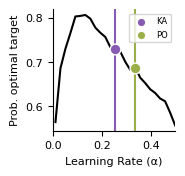

In [37]:
alpha_range, res_grid_qlearn_inferential = grid_search_RL(env, n_samples=25)
fig, ax = plot_parameter_grid_RL(alpha_range, res_grid_qlearn_inferential)
plt.show()

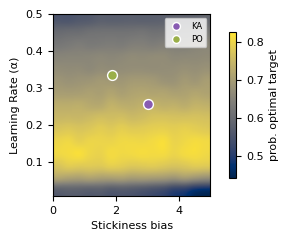

In [ ]:
'''alpha_range, stickiness_range, res_grid_qlearn_inferential = grid_search_sRL(env)
fig, ax = plot_parameter_grid_sRL(alpha_range, stickiness_range, res_grid_qlearn_inferential)
plt.show()'''

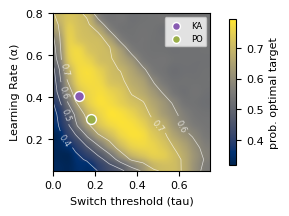

In [ ]:
alpha_range_forage, V0_range_forage, res_grid_foraging = grid_search_foraging(env)
fig, ax = plot_parameter_grid_foraging(alpha_range_forage, V0_range_forage, res_grid_foraging, parameter_summary_df)
plt.show()
